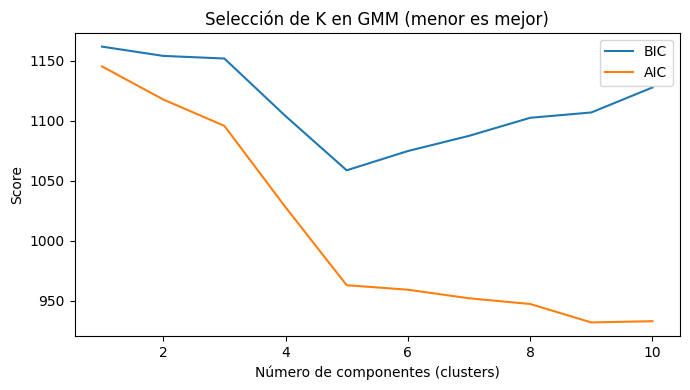

Mejor K según BIC: 5


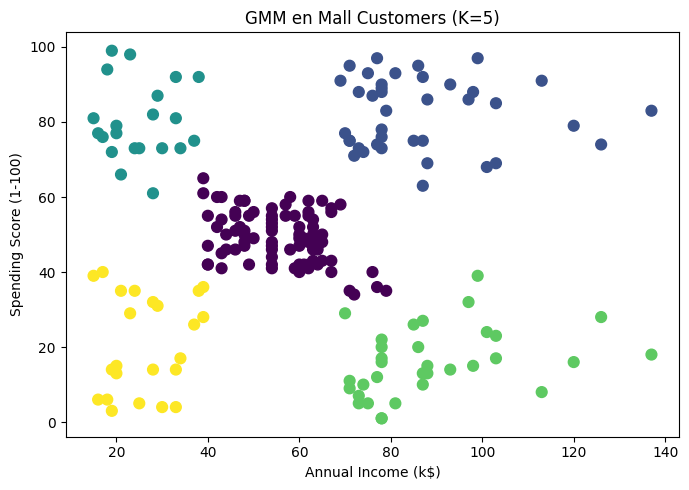


Top 10 puntos más ambiguos (menor confianza):
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
124         125  Female   23                  70                      29   
48           49  Female   29                  40                      42   
49           50  Female   31                  40                      42   
27           28    Male   35                  28                      61   
160         161  Female   56                  79                      35   
55           56    Male   47                  43                      41   
45           46  Female   24                  39                      65   
47           48  Female   27                  40                      47   
146         147    Male   48                  77                      36   
132         133  Female   25                  72                      34   

     cluster_gmm  confidence  
124            3    0.502932  
48             0    0.611381  
49             0    0.6

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# 1) Cargar dataset
df = pd.read_csv("Mall_Customers.csv")

# 2) Variables para clustering (las mismas típicas para visualizar)
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].to_numpy()

# 3) Escalar (muy recomendado para GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Elegir número de clusters con BIC/AIC
ks = range(1, 11)
bics, aics = [], []

for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

plt.figure(figsize=(7,4))
plt.plot(list(ks), bics, label="BIC")
plt.plot(list(ks), aics, label="AIC")
plt.title("Selección de K en GMM (menor es mejor)")
plt.xlabel("Número de componentes (clusters)")
plt.ylabel("Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

best_k = ks[int(np.argmin(bics))]
print("Mejor K según BIC:", best_k)

# 5) Entrenar el modelo final
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_scaled)

# 6) Etiquetas (hard) + probabilidades (soft)
labels = gmm.predict(X_scaled)                 # cluster más probable
probs = gmm.predict_proba(X_scaled)            # probabilidades por cluster
confidence = probs.max(axis=1)                 # "seguridad" por punto

# 7) Visualización
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=labels, s=60)
plt.title(f"GMM en Mall Customers (K={best_k})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

# 8) Ejemplo de interpretación: puntos más "ambiguos"
df_out = df.copy()
df_out["cluster_gmm"] = labels
df_out["confidence"] = confidence

print("\nTop 10 puntos más ambiguos (menor confianza):")
print(df_out.sort_values("confidence").head(10)[
    ["CustomerID","Gender","Age","Annual Income (k$)","Spending Score (1-100)","cluster_gmm","confidence"]
])